In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns= housing.feature_names)
df['PRICE'] = housing.target

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


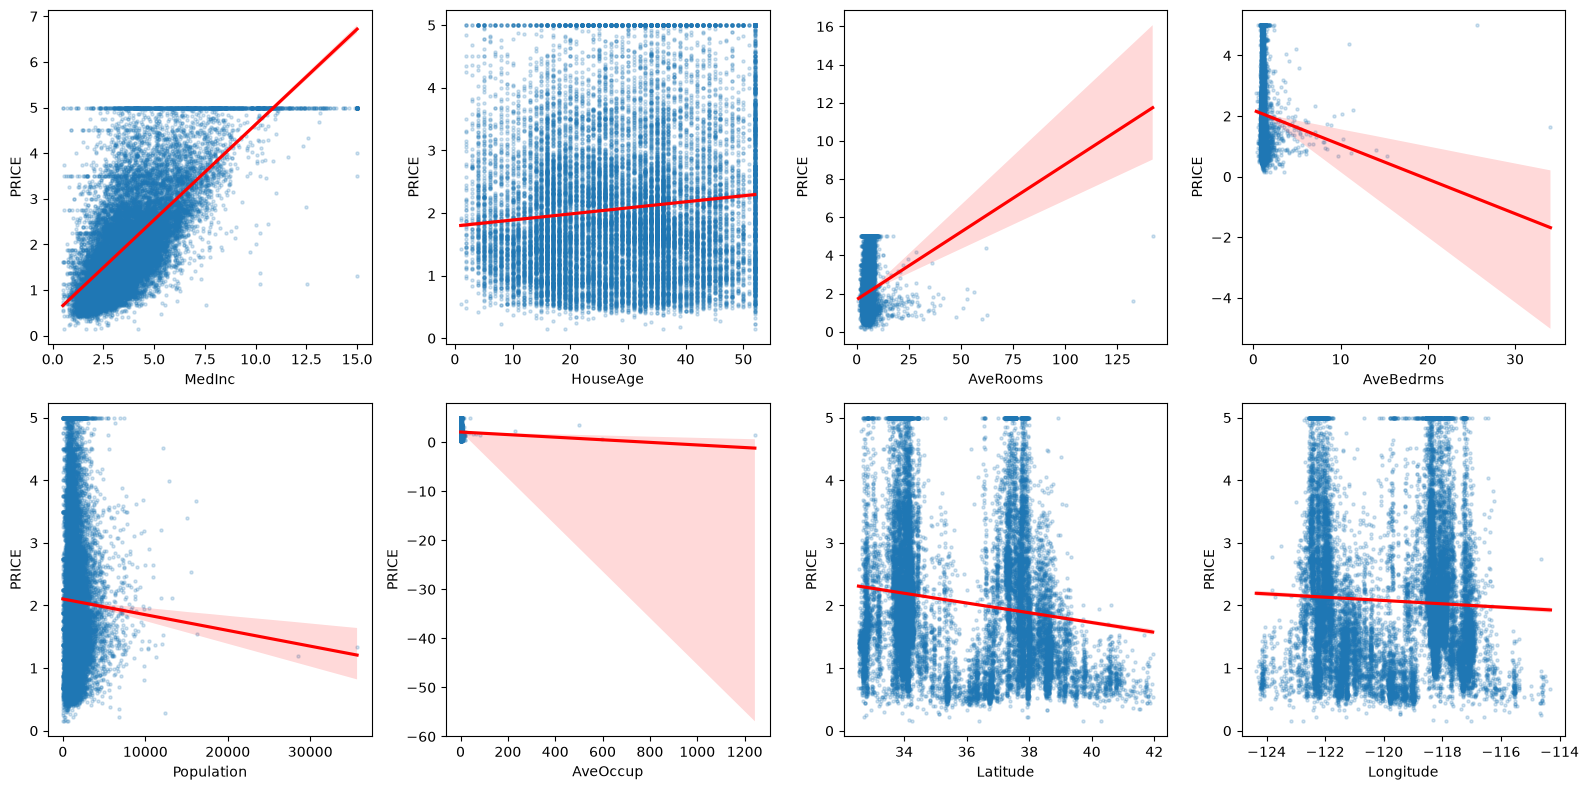

In [5]:
fig, axes = plt.subplots(figsize=(16,8),ncols=4,nrows=2)
lm_features = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']

for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i % 4
    sns.regplot(x = feature, y='PRICE', data = df, ax = axes[row][col],scatter_kws={'s':5,'alpha':0.2}, line_kws={'color':'red'})

plt.tight_layout()

fig1 = plt.gcf()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = df['PRICE']
X_data = df.drop(['PRICE'], axis=1, inplace= False)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_target,
                                                    test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print(mse)
print(rmse)
print(r2_score(y_test, pred))

0.5558915986952442
0.7455813830127763
0.575787706032451


In [7]:
print(lr.intercept_)
print(np.round(lr.coef_,3))

-37.02327770606416
[ 0.449  0.01  -0.123  0.783 -0.    -0.004 -0.42  -0.434]


In [8]:
coeff = pd.Series(data = np.round(lr.coef_,3), index = X_data.columns)
coeff.sort_values(ascending=False)

AveBedrms     0.783
MedInc        0.449
HouseAge      0.010
Population   -0.000
AveOccup     -0.004
AveRooms     -0.123
Latitude     -0.420
Longitude    -0.434
dtype: float64

In [9]:
from sklearn.model_selection import cross_val_score

y_target = df['PRICE']
X_data = df.drop(["PRICE"], axis=1, inplace=False)
lr = LinearRegression()

neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring= 'neg_mean_squared_error', cv = 5)

rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(np.round(neg_mse_scores,2))
print(np.round(rmse_scores,2))
print(avg_rmse)

[-0.48 -0.62 -0.65 -0.54 -0.49]
[0.7  0.79 0.8  0.74 0.7 ]
0.7459068363518113


In [10]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

X = np.arange(4).reshape(2,2)
print('일차 단항식 계수:', X)

poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수:', poly_ftr)

일차 단항식 계수: [[0 1]
 [2 3]]
변환된 2차 다항식 계수: [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [11]:
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    print(X[:,0])
    print(X[:,1])
    return y

X = np.arange(0,4).reshape(2,2)

print('일차 단항식 계수:',X)
y = polynomial_func(X)
print('삼차 다항식 결정값:',y)

일차 단항식 계수: [[0 1]
 [2 3]]
[0 2]
[1 3]
삼차 다항식 결정값: [  5 125]


In [12]:
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)

print('3차 다항식 계수:', poly_ftr)

model = LinearRegression()
model.fit(poly_ftr, y)
print('회귀계수:',np.round(model.coef_,2))
print('회귀 shape:',model.coef_.shape)

3차 다항식 계수: [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
회귀계수: [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
회귀 shape: (10,)


In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 2 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y

model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])

X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X,y)
print('회귀계수:', np.round(model.named_steps['linear'].coef_,2))

회귀계수: [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30
X= np.sort(np.random.rand(n_samples))

y = true_fun(X) + np.random.randn(n_samples) * 0.1

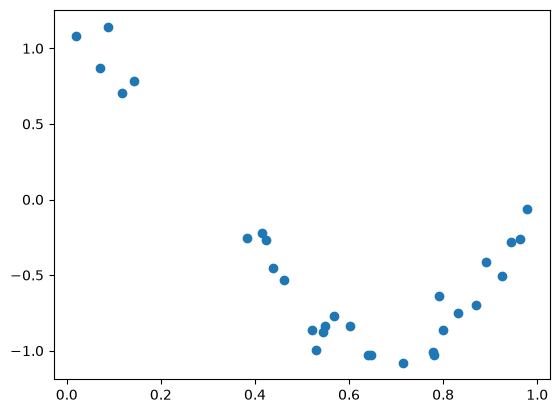

In [15]:
plt.scatter(X,y)

Degree: 1
회귀계수:: [-1.61]
MSE 0.4077289625098685
Degree: 4
회귀계수:: [  0.47 -17.79  23.59  -7.26]
MSE 0.04320874987232056
Degree: 15
회귀계수:: [    3.29   -83.83   474.97 -1211.36  1006.92   668.01  -659.73  -935.56
  -134.     746.87   885.29   168.    -810.43  -990.04   871.11]
MSE 0.21959838159883258


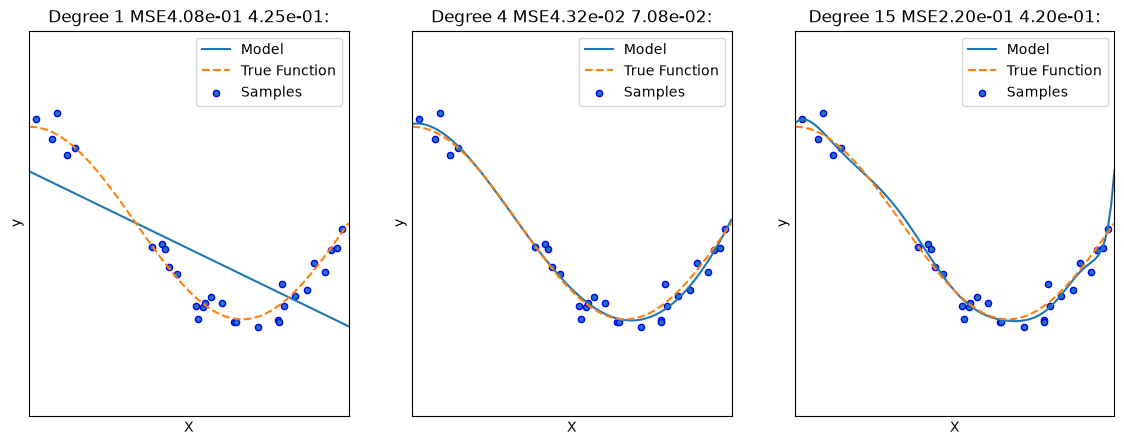

In [16]:
plt.figure(figsize=(14,5))
degrees = [1,4,15]

for i  in range(len(degrees)):
    ax = plt.subplot(1,len(degrees), i +1)
    plt.setp(ax, xticks = (), yticks = ())
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)

    linear_regression = LinearRegression()
    pipeline = Pipeline([('polynomial_features', polynomial_features),
                         ('linear_regression', linear_regression)])

    pipeline.fit(X.reshape(-1,1),y)

    scores = cross_val_score(pipeline, X.reshape(-1,1),y,scoring='neg_mean_squared_error',cv=10)

    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('Degree:', degrees[i])
    print('회귀계수::', np.round(coefficients,2))
    print('MSE',-1*np.mean(scores))

    X_test = np.linspace(0,1,100)
    plt.plot(X_test, pipeline.predict(X_test[:,np.newaxis]), label='Model')
    plt.plot(X_test, true_fun(X_test),'--',label= 'True Function')
    plt.scatter(X,y,edgecolor = 'b', s = 20, label = 'Samples')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.xlim((0,1))
    plt.ylim((-2,2))
    plt.legend(loc='best')
    plt.title("Degree {} MSE{:.2e} {:.2e}:".format(degrees[i], -scores.mean(), scores.std()))
plt.show()

In [17]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns = housing.feature_names)

df['PRICE'] = housing.target

y_target = df['PRICE']
X_data = df.drop(['PRICE'],axis=1 , inplace= False)

ridge = Ridge(alpha=10)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring='neg_mean_squared_error', cv=5)

rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rsme = np.mean(rmse_scores)
print('Negative MSE:', np.round(neg_mse_scores,3))
print('RMSE:', np.round(rmse_scores,3))
print('Average RSME:', avg_rsme)

Negative MSE: [-0.484 -0.623 -0.646 -0.544 -0.494]
RMSE: [0.695 0.789 0.804 0.737 0.703]
Average RSME: 0.745820729297258


In [18]:
alphas = [0,0.1,1,10,100]

for alpha in alphas:
    ridge = Ridge(alpha=alpha)

    neg_mse_scores = cross_val_score(ridge, X_data,y_target,scoring='neg_mean_squared_error', cv=5)

    avg_rsme = np.mean(np.sqrt(-1*neg_mse_scores))
    print('alpha: {0}, RSME: {1:.3f}'.format(alpha, avg_rmse))

alpha: 0, RSME: 0.746
alpha: 0.1, RSME: 0.746
alpha: 1, RSME: 0.746
alpha: 10, RSME: 0.746
alpha: 100, RSME: 0.746


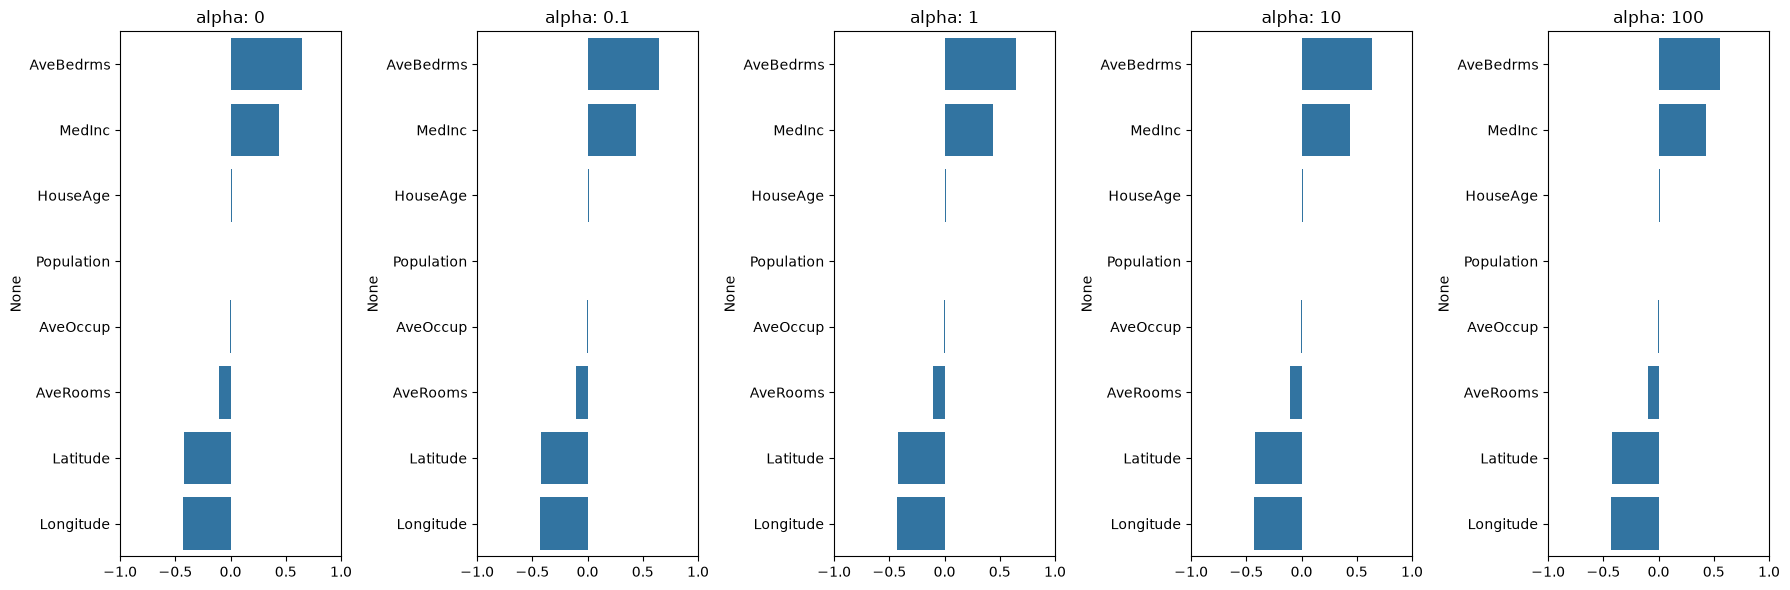

In [19]:
fig, axes = plt.subplots(figsize = (18,6), nrows=1, ncols=5)

coeff_df = pd.DataFrame()

for pos, alpha in enumerate(alphas):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_data,y_target)
    coeff = pd.Series(data = ridge.coef_, index = X_data.columns)
    colname = 'alpha: ' + str(alpha)
    coeff_df[colname] = coeff
    coeff = coeff.sort_values(ascending = False)
    axes[pos].set_title(colname)
    axes[pos].set_xlim(-1,1)
    sns.barplot( x = coeff.values, y= coeff.index, ax = axes[pos])

plt.tight_layout()
plt.show()

In [20]:
ridge_alpha = [0,0.1,1,10,100]
sort_column = 'alpha: ' + str(ridge_alpha[0])
coeff_df.sort_values(by= sort_column, ascending= False)

,alpha: 0,alpha: 0.1,alpha: 1,alpha: 10,alpha: 100
AveBedrms,0.645066,0.644965,0.644062,0.635174,0.558249
MedInc,0.436693,0.436683,0.436594,0.435719,0.428210
HouseAge,0.009436,0.009436,0.009437,0.009452,0.009592
Population,-0.000004,-0.000004,-0.000004,-0.000004,-0.000003
AveOccup,-0.003787,-0.003787,-0.003786,-0.003785,-0.003773
AveRooms,-0.107322,-0.107303,-0.107133,-0.105456,-0.091012
Latitude,-0.421314,-0.421313,-0.421299,-0.421156,-0.419061
Longitude,-0.434514,-0.434511,-0.434485,-0.434217,-0.430993


In [21]:
from sklearn.linear_model import Lasso, ElasticNet

def get_linear_reg_eval(model_name, params = None, X_data_n = None, y_target_n = None, verbose = True, return_coeff = True):

    coeff_df = pd.DataFrame()
    if verbose : print("######", model_name, "######")

    for param in params:
        if model_name == "Ridge": model = Ridge(alpha = param)
        elif model_name == "Lasso": model = Lasso(alpha = param)
        elif model_name == "ElasticNet":
            model = ElasticNet(alpha = param, l1_ratio = 0.87)

        neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring = "neg_mean_squared_error", cv = 5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
        
        print("alpha {0} RMSE {1}".format(param, avg_rmse))

        model.fit(X_data_n, y_target_n)

        if return_coeff:
            coeff = pd.Series(data = model.coef_, index = X_data_n.columns)
            colname = "alpha: " + str(param)
            coeff_df[colname] = coeff

    return coeff_df

In [22]:
lasso_alpha = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval('Lasso',params= lasso_alpha, X_data_n = X_data, y_target_n= y_target)

###### Lasso ######
alpha 0.07 RMSE 0.7843330816065585
alpha 0.1 RMSE 0.8126415820543167
alpha 0.5 RMSE 0.8726693609660868
alpha 1 RMSE 0.999589987374003
alpha 3 RMSE 1.1710496863773499


In [23]:
sort_column = 'alpha: ' + str(lasso_alpha[0])
coeff_lasso_df.sort_values(by=sort_column, ascending=False)

,alpha: 0.07,alpha: 0.1,alpha: 0.5,alpha: 1,alpha: 3
MedInc,0.387057,0.390583,0.288855,0.145469,0.000000
HouseAge,0.013391,0.015082,0.012031,0.005815,0.000000
Population,0.000010,0.000018,0.000012,-0.000006,-0.000023
AveRooms,-0.000000,-0.000000,0.000000,0.000000,0.000000
AveBedrms,0.000000,0.000000,-0.000000,0.000000,0.000000
AveOccup,-0.003409,-0.003323,-0.000000,-0.000000,-0.000000
Longitude,-0.204689,-0.099225,-0.000000,-0.000000,0.000000
Latitude,-0.212806,-0.114214,-0.000000,-0.000000,0.000000


In [24]:
elastic_alpha = [0.07, 0.1,0.5,1,3]

coeff_elastic_df = get_linear_reg_eval('Lasso', params= elastic_alpha, X_data_n=X_data, y_target_n= y_target)

###### Lasso ######
alpha 0.07 RMSE 0.7843330816065585
alpha 0.1 RMSE 0.8126415820543167
alpha 0.5 RMSE 0.8726693609660868
alpha 1 RMSE 0.999589987374003
alpha 3 RMSE 1.1710496863773499


In [25]:
sort_column = 'alpha: ' + str(elastic_alpha[0])
coeff_elastic_df.sort_values(by=sort_column, ascending = False)

,alpha: 0.07,alpha: 0.1,alpha: 0.5,alpha: 1,alpha: 3
MedInc,0.387057,0.390583,0.288855,0.145469,0.000000
HouseAge,0.013391,0.015082,0.012031,0.005815,0.000000
Population,0.000010,0.000018,0.000012,-0.000006,-0.000023
AveRooms,-0.000000,-0.000000,0.000000,0.000000,0.000000
AveBedrms,0.000000,0.000000,-0.000000,0.000000,0.000000
AveOccup,-0.003409,-0.003323,-0.000000,-0.000000,-0.000000
Longitude,-0.204689,-0.099225,-0.000000,-0.000000,0.000000
Latitude,-0.212806,-0.114214,-0.000000,-0.000000,0.000000


In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

def get_scaled_data(method = 'None', p_degree = None, input_data = None):
    if method == 'Standard':
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == 'MinMax':
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == 'Log':
        scaled_data = input_data.copy()
        positive_cols = scaled_data.columns[(scaled_data >= 0).all()]
        scaled_data[positive_cols] = np.log1p(scaled_data[positive_cols])

    else:
        scaled_data = input_data

    if p_degree != None:
        scaled_data = PolynomialFeatures(degree= p_degree, include_bias= False).fit_transform(scaled_data)

    return scaled_data

In [28]:
alphas = [0.1,1,10,100]

scaled_methods = [(None,None), ('Standard', None), ('Standard', 2), ('MinMax', None), ('MinMax',2), ('Log', None)]

for scaled_method in scaled_methods:
    X_data_scaled = get_scaled_data(method= scaled_method[0],
                                   p_degree= scaled_method[1], input_data= X_data)
    print(X_data_scaled.shape, X_data.shape)
    print(scaled_method[0], scaled_method[1])
    get_linear_reg_eval('Ridge', params= alphas, X_data_n= X_data_scaled, y_target_n= y_target, verbose= False, return_coeff= False)

(20640, 8) (20640, 8)
None None
alpha 0.1 RMSE 0.7459058975815243
alpha 1 RMSE 0.7458975215245666
alpha 10 RMSE 0.745820729297258
alpha 100 RMSE 0.7455621549159899
(20640, 8) (20640, 8)
Standard None
alpha 0.1 RMSE 0.7459062101326919
alpha 1 RMSE 0.7459006592292845
alpha 10 RMSE 0.7458534119763472
alpha 100 RMSE 0.7460698057804251
(20640, 44) (20640, 8)
Standard 2
alpha 0.1 RMSE 3.322648006406444
alpha 1 RMSE 2.850331833488543
alpha 10 RMSE 1.313763176046886
alpha 100 RMSE 0.7186881531785737
(20640, 8) (20640, 8)
MinMax None
alpha 0.1 RMSE 0.7446135691916066
alpha 1 RMSE 0.747698395099562
alpha 10 RMSE 0.753910122049269
alpha 100 RMSE 0.8162438280708215
(20640, 44) (20640, 8)
MinMax 2
alpha 0.1 RMSE 0.7257311172484077
alpha 1 RMSE 0.7424165229389478
alpha 10 RMSE 0.7553401447762835
alpha 100 RMSE 0.7890551890075603
(20640, 8) (20640, 8)
Log None
alpha 0.1 RMSE 0.7305763496807778
alpha 1 RMSE 0.7315332186967523
alpha 10 RMSE 0.7542834302658961
alpha 100 RMSE 0.795037262770435
